# Ecommerce Product Category Classification

В проекте используется датасет товаров электронной коммерции.

Каждый объект содержит:

- `description` — текстовое описание товара  
- `category` — категория товара (целевая переменная)

Размер датасета:
- ~50 000 объектов
- 2 колонки

Задача: по текстовому описанию определить категорию товара.

На вход модели подаётся:
- текстовое описание товара (`description`)

На выходе:
- категория товара (`category`)

Цель ноутбука:

1. Провести базовый анализ данных (EDA)
2. Подготовить текст для моделирования
3. Построить baseline модель (TF-IDF + Logistic Regression)
4. Сравнить несколько подходов:
   - TF-IDF
   - embeddings
   - transformer (BERT)
5. Залогировать эксперименты в MLflow
6. Выбрать модель для production inference сервиса

Важно: модель будет выбираться не только по качеству, но и по latency и простоте деплоя.

## Imports

In [22]:
import pandas as pd
import numpy as np
import os
import json
import time

import mlflow
import mlflow.sklearn

import matplotlib.pyplot as plt

from datasets import Dataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from transformers import (
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    AutoModelForSequenceClassification
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report
)

from sklearn.preprocessing import LabelEncoder

## Fast-check

In [23]:
df = pd.read_csv('data/raw/ecommerceDataset.csv')
df.head()

,category,description
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...


In [24]:
print(df.shape)
df.info()

(50425, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50425 entries, 0 to 50424
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   category     50425 non-null  object
 1   description  50424 non-null  object
dtypes: object(2)
memory usage: 788.0+ KB


только 1 пропуск в описании товара

## EDA

Посмотрим на распределение классов

category
Household                 19313
Books                     11820
Electronics               10621
Clothing & Accessories     8671
Name: count, dtype: int64

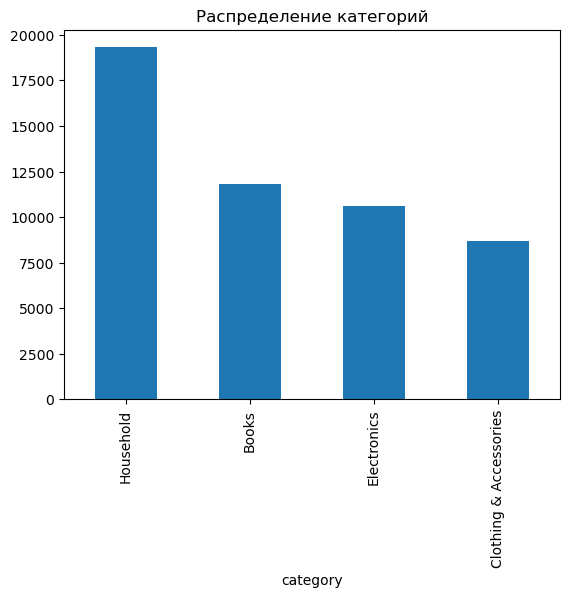

In [25]:
class_dist = df['category'].value_counts()
display(class_dist.head())

class_dist.plot(kind='bar')
plt.title('Распределение категорий')
plt.show()

Критичного дисбаланса в данных нет, но категория "Clothing & Accessories" немного отстаёт от остальных

Взглянем на распределение длин текстов

count    50425.000000
mean       714.098185
std        973.370093
min          0.000000
25%        219.000000
50%        487.000000
75%        954.000000
max      50403.000000
Name: text_length, dtype: float64

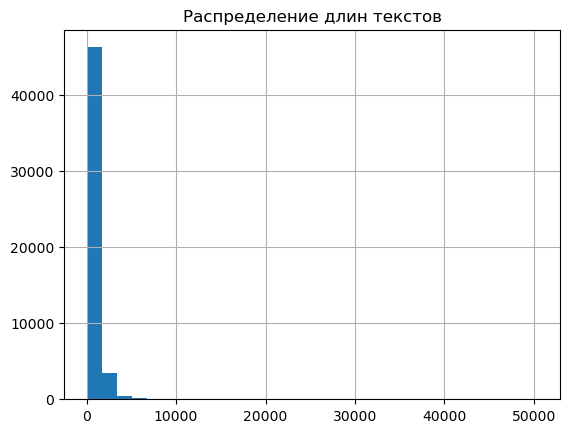

In [26]:
df['text_length'] = df['description'].fillna('').apply(len)
display(df['text_length'].describe())

df['text_length'].hist(bins=30)
plt.title('Распределение длин текстов')
plt.show()

In [27]:
print('Число объектов в длиной текста больше 10000:',
      len(df[df['text_length'] > 10000]))

Число объектов в длиной текста больше 10000: 55


Большинство текстов короткие(< 1000 слов), но есть несколько(55) очень длинных текстов. 

Так как их очень мало, будем обрезать текст(у BERT ограничение в 512 токенов + latency будет расти)

In [28]:
df = df[df['description'].str.len() < 10000]

Посмотрим на несколько сэмплов текста

In [29]:
for text in df['description'].head(5):
    print(text)
    print('-' * 50)

Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set of 4 Painting made up in synthetic frame with uv textured print which gives multi effects and attracts towards it. This is an special series of paintings which makes your wall very beautiful and gives a royal touch. This painting is ready to hang, you would be proud to possess this unique painting that is a niche apart. We use only the most modern and efficient printing technology on our prints, with only the and inks and precision epson, roland and hp printers. This innovative hd printing technique results in durable and spectacular looking prints of the highest that last a lifetime. We print solely with top-notch 100% inks, to achieve brilliant and true colours. Due to their high level of uv resistance, our prints retain their beautiful colours for many years. Add colour and style to your living space with this digitally printed painting. Some are for pleasure and some for eternal bliss

Посмотрим, есть ли пустые тексты

In [30]:
df[df['description'].str.strip() == '']

,category,description,text_length


Избавимся от единственного пропуска

In [31]:
df = df.dropna()

### Итоги EDA:

- В данных присутствует дисбаланс, но он не критичен
- В среднем тексты имеют длинну 700 символов, но есть и хвост до 50к, который был обрезан до 10к символов
- Единственный пропуск был удалён
- Тексты выглядят корректно
- В качестве основной метрики будем использовать f1_macro(простая, интерпретируемая и подходит под задачу)

## 4. Baseline Model — TF-IDF + Logistic Regression

### 4.1 Train-test split

In [32]:
X = df['description']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (40295,)
Test size: (10074,)


### 4.2 TF-IDF vectorization

In [33]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print('Train shape:', X_train_tfidf.shape)
print('Test shape:', X_test_tfidf.shape)

Train shape: (40295, 20000)
Test shape: (10074, 20000)


### 4.3 Logistic Regression training

In [34]:
clf = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

clf.fit(X_train_tfidf, y_train)

c:\Users\79104\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [35]:
y_pred = clf.predict(X_test_tfidf)
y_pred[:10]

array(['Clothing & Accessories', 'Household', 'Electronics', 'Household',
       'Clothing & Accessories', 'Books', 'Household',
       'Clothing & Accessories', 'Household', 'Electronics'], dtype=object)

In [36]:
print(classification_report(y_test, y_pred))

                        precision    recall  f1-score   support

                 Books       0.98      0.95      0.96      2355
Clothing & Accessories       0.98      0.98      0.98      1734
           Electronics       0.96      0.95      0.96      2123
             Household       0.96      0.98      0.97      3862

              accuracy                           0.97     10074
             macro avg       0.97      0.97      0.97     10074
          weighted avg       0.97      0.97      0.97     10074



Baseline модель TF-IDF + Logistic Regression показала очень высокое качество на тестовой выборке

Это говорит о том, что для данного датасета категории хорошо разделимы по текстовому описанию, а простая линейная модель на TF-IDF признаках уже решает задачу на высоком уровне.

Следовательно, для текущего проекта TF-IDF + Logistic Regression является сильным кандидатом на роль финальной модели.

Дальнейшее сравнение с более сложными подходами остаётся полезным скорее как демонстрация MLOps-подхода и анализа trade-offs, чем как обязательный способ заметно улучшить качество.

## 5. Model Comparison with MLflow

Несмотря на то, что baseline модель TF-IDF + Logistic Regression уже показала очень высокое качество, дальнейшее сравнение моделей остаётся полезным как часть MLOps-процесса.

для всех запусков фиксируется единая схема логирования в MLflow.

#### Logged parameters
- `model_family` — семейство модели (tfidf, embeddings, transformer)
- `vectorizer_type` — тип векторизации
- `classifier_type` — тип классификатора
- `max_features` — ограничение словаря TF-IDF
- `ngram_range` — используемый диапазон n-грамм
- `embedding_model_name` — название embedding-модели
- `test_size` — доля тестовой выборки

#### Logged metrics
- `accuracy`
- `f1_macro`
- `precision_macro`
- `recall_macro`

#### Logged artifacts
- classification report
- confusion matrix
- обученная модель или pipeline
- дополнительные вспомогательные файлы эксперимента

In [37]:
# принимает векторайзер, классификатор и параметры логирования
# для повторения экспериментов
def run_sklearn_experiment(
        run_name,
        vectorizer,
        classifier,
        X_train,
        X_test, 
        y_train,
        y_test,
        params_to_log
):
    fit_transform_start = time.perf_counter()
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    vectorization_time_sec = time.perf_counter() - fit_transform_start

    train_start = time.perf_counter()
    classifier.fit(X_train_vec, y_train)
    train_time_sec = time.perf_counter() - train_start

    infer_start = time.perf_counter()
    y_pred = classifier.predict(X_test_vec)
    infer_time_sec = time.perf_counter() - infer_start

    avg_infer_ms_per_sample = (infer_time_sec / len(X_test)) * 1000

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')

    report_dict = classification_report(y_test, y_pred, output_dict=True)

    with mlflow.start_run(run_name=run_name):
        for key, value in params_to_log.items():
            mlflow.log_param(key, value)
        
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_macro", f1)
        mlflow.log_metric("precision_macro", precision)
        mlflow.log_metric("recall_macro", recall)
        mlflow.log_metric("vectorization_time_sec", vectorization_time_sec)
        mlflow.log_metric("train_time_sec", train_time_sec)
        mlflow.log_metric("infer_time_sec_on_test", infer_time_sec)
        mlflow.log_metric("avg_infer_ms_per_sample", avg_infer_ms_per_sample)

        if hasattr(vectorizer, 'vocabulary_'):
            mlflow.log_metric('vocab_size', len(vectorizer.vocabulary_))

        report_path = f"artifacts/{run_name}_classification_report.json"
        with open(report_path, 'w', encoding='utf-8') as f:
            json.dump(report_dict, f, ensure_ascii=False, indent=2)
        
        mlflow.log_artifact(report_path)

    return {
        "run_name": run_name,
        "accuracy": acc,
        "f1_macro": f1,
        "precision_macro": precision,
        "recall_macro": recall,
        "vectorization_time_sec": vectorization_time_sec,
        "train_time_sec": train_time_sec,
        "infer_time_sec_on_test": infer_time_sec,
        "avg_infer_ms_per_sample": avg_infer_ms_per_sample,
        "vectorizer": vectorizer,
        "classifier": classifier,
    }

In [38]:
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("text-classification")

<Experiment: artifact_location='file:c:/Users/79104/ml-category-service/mlruns/531079699176523948', creation_time=1774416593173, experiment_id='531079699176523948', last_update_time=1774416593173, lifecycle_stage='active', name='text-classification', tags={}, workspace='default'>

In [39]:
baseline_result = run_sklearn_experiment(
    run_name="tfidf_logreg_baseline",
    vectorizer=TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        stop_words="english",
    ),
    classifier=LogisticRegression(
        max_iter=1000,
        n_jobs=-1,
    ),
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    params_to_log={
        "model_family": "tfidf",
        "vectorizer_type": "tfidf",
        "classifier_type": "logistic_regression",
        "max_features": 20000,
        "ngram_range": "(1, 2)",
        "stop_words": "english",
        "test_size": 0.2,
    },
)

baseline_result

c:\Users\79104\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


{'run_name': 'tfidf_logreg_baseline',
 'accuracy': 0.96793726424459,
 'f1_macro': 0.968177990114081,
 'precision_macro': 0.9699050105528368,
 'recall_macro': 0.9665806562359129,
 'vectorization_time_sec': 7.805587999999716,
 'train_time_sec': 1.9657649000000674,
 'infer_time_sec_on_test': 0.0032901999998102838,
 'avg_infer_ms_per_sample': 0.0003266031367689382,
 'vectorizer': TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words='english'),
 'classifier': LogisticRegression(max_iter=1000, n_jobs=-1)}

Проверим, можем ли сделать модель проще и быстрее, не потеряв сильно в качестве

In [40]:
light_result = run_sklearn_experiment(
    run_name="tfidf_logreg_light",
    vectorizer=TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 1),
        stop_words="english",
    ),
    classifier=LogisticRegression(
        max_iter=1000,
        n_jobs=-1,
    ),
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    params_to_log={
        "model_family": "tfidf",
        "vectorizer_type": "tfidf",
        "classifier_type": "logistic_regression",
        "max_features": 10000,
        "ngram_range": "(1, 1)",
        "stop_words": "english",
        "test_size": 0.2,
    },
)

light_result

c:\Users\79104\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


{'run_name': 'tfidf_logreg_light',
 'accuracy': 0.9672424061941632,
 'f1_macro': 0.9675776073630966,
 'precision_macro': 0.9693679299592391,
 'recall_macro': 0.9658990344439847,
 'vectorization_time_sec': 2.7168335000001207,
 'train_time_sec': 1.4299275999997008,
 'infer_time_sec_on_test': 0.002841500000158703,
 'avg_infer_ms_per_sample': 0.00028206273577116375,
 'vectorizer': TfidfVectorizer(max_features=10000, stop_words='english'),
 'classifier': LogisticRegression(max_iter=1000, n_jobs=-1)}

Light-конфигурация показала сопоставимое качество при более лёгком признаковом пространстве и, вероятно, более дешёвом pipeline

Посмотрим, помогут ли эмбеддинги улучшить качество модели

In [41]:
def run_embedding_experiment(
    run_name,
    embedder,
    classifier,
    X_train,
    X_test,
    y_train,
    y_test,
    params_to_log,
    batch_size=64,
):
    embed_start = time.perf_counter()
    X_train_emb = embedder.encode(
        X_train.tolist(),
        show_progress_bar=True,
        batch_size=batch_size,
    )
    X_test_emb = embedder.encode(
        X_test.tolist(),
        show_progress_bar=True,
        batch_size=batch_size,
    )
    embedding_time_sec = time.perf_counter() - embed_start

    train_start = time.perf_counter()
    classifier.fit(X_train_emb, y_train)
    train_time_sec = time.perf_counter() - train_start

    infer_start = time.perf_counter()
    y_pred = classifier.predict(X_test_emb)
    infer_time_sec = time.perf_counter() - infer_start
    avg_infer_ms_per_sample = (infer_time_sec / len(X_test_emb)) * 1000

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    precision = precision_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")

    report_dict = classification_report(y_test, y_pred, output_dict=True)

    with mlflow.start_run(run_name=run_name):
        for key, value in params_to_log.items():
            mlflow.log_param(key, value)

        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_macro", f1)
        mlflow.log_metric("precision_macro", precision)
        mlflow.log_metric("recall_macro", recall)
        mlflow.log_metric("embedding_time_sec", embedding_time_sec)
        mlflow.log_metric("train_time_sec", train_time_sec)
        mlflow.log_metric("infer_time_sec_on_test", infer_time_sec)
        mlflow.log_metric("avg_infer_ms_per_sample", avg_infer_ms_per_sample)
        mlflow.log_metric("embedding_dim", X_train_emb.shape[1])

        report_path = f"artifacts/{run_name}_classification_report.json"
        with open(report_path, "w", encoding="utf-8") as f:
            json.dump(report_dict, f, ensure_ascii=False, indent=2)

        mlflow.log_artifact(report_path)

    return {
        "run_name": run_name,
        "accuracy": acc,
        "f1_macro": f1,
        "precision_macro": precision,
        "recall_macro": recall,
        "embedding_time_sec": embedding_time_sec,
        "train_time_sec": train_time_sec,
        "infer_time_sec_on_test": infer_time_sec,
        "avg_infer_ms_per_sample": avg_infer_ms_per_sample,
        "embedder": embedder,
        "classifier": classifier,
    }

In [42]:
embedding_result = run_embedding_experiment(
    run_name="embeddings_minilm_logreg",
    embedder=SentenceTransformer("all-MiniLM-L6-v2"),
    classifier=LogisticRegression(
        max_iter=1000,
        n_jobs=-1,
    ),
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    params_to_log={
        "model_family": "embeddings",
        "embedding_model_name": "all-MiniLM-L6-v2",
        "classifier_type": "logistic_regression",
        "test_size": 0.2,
        "batch_size": 64,
    },
    batch_size=64,
)

embedding_result

Batches:   0%|          | 0/630 [00:00<?, ?it/s]

Batches:   0%|          | 0/158 [00:00<?, ?it/s]

c:\Users\79104\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


{'run_name': 'embeddings_minilm_logreg',
 'accuracy': 0.9470915227317848,
 'f1_macro': 0.9480259086118172,
 'precision_macro': 0.9490600639186677,
 'recall_macro': 0.9471474551714207,
 'embedding_time_sec': 40.49188940000022,
 'train_time_sec': 0.7460759000000508,
 'infer_time_sec_on_test': 0.011848300000110612,
 'avg_infer_ms_per_sample': 0.0011761266627070292,
 'embedder': SentenceTransformer(
   (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
   (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
   (2): Normalize()
 ),
 'classifier': LogisticRegression(max_iter=1000, n_jobs=-1)}

Embedding-based подход показал более низкое качество по сравнению с TF-IDF baseline (~2% разницы в F1_macro).

Это можно объяснить спецификой датасета: тексты представляют собой короткие keyword-style описания товаров, где наличие конкретных слов напрямую связано с категорией.

Несмотря на это, также посмотрим, как справится с задачей BERT-модель

In [43]:
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

num_labels = len(label_encoder.classes_)

train_df = pd.DataFrame({
    "text": X_train.tolist(),
    "label": y_train_enc,
})

test_df = pd.DataFrame({
    "text": X_test.tolist(),
    "label": y_test_enc,
})

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

In [44]:
model_name = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [45]:
def tokenize_function(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        padding='max_length',
        max_length=256
    )

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "precision_macro": precision_score(labels, preds, average="macro"),
        "recall_macro": recall_score(labels, preds, average="macro"),
    }

In [46]:
train_dataset_tok = train_dataset.map(tokenize_function, batched=True)
test_dataset_tok = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/40295 [00:00<?, ? examples/s]

Map:   0%|          | 0/10074 [00:00<?, ? examples/s]

In [53]:
training_args = TrainingArguments(
    output_dir='distilbert_results',
    eval_strategy='epoch',
    save_strategy='no',
    logging_strategy='epoch',
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    report_to='none'
)

In [54]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_tok,
    eval_dataset=test_dataset_tok,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)
train_start = time.perf_counter()

with mlflow.start_run(run_name="distilbert_classifier"):
    mlflow.log_param("model_family", "transformer")
    mlflow.log_param("model_name", model_name)
    mlflow.log_param("max_length", 256)
    mlflow.log_param("num_train_epochs", 1)
    mlflow.log_param("per_device_train_batch_size", 16)
    mlflow.log_param("per_device_eval_batch_size", 16)
    mlflow.log_param("weight_decay", 0.01)
    mlflow.log_param("test_size", 0.2)

    train_start = time.perf_counter()
    trainer.train()
    train_time_sec = time.perf_counter() - train_start

    pred_start = time.perf_counter()
    preds_output = trainer.predict(test_dataset_tok)
    pred_time_sec = time.perf_counter() - pred_start

    y_pred = preds_output.predictions.argmax(axis=1)
    y_true = preds_output.label_ids

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    precision = precision_score(y_true, y_pred, average="macro")
    recall = recall_score(y_true, y_pred, average="macro")

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_macro", f1)
    mlflow.log_metric("precision_macro", precision)
    mlflow.log_metric("recall_macro", recall)

    mlflow.log_metric("train_time_sec", train_time_sec)
    mlflow.log_metric("predict_time_sec", pred_time_sec)

    

distilbert_eval

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\79104\AppData\Local\Temp\ipykernel_9372\484561385.py:6: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.177300,0.118695,0.972702,0.973115,0.974214,0.972064
2,0.067800,0.099879,0.980246,0.980375,0.980863,0.979917


{'eval_loss': 0.11651966720819473,
 'eval_accuracy': 0.973198332340679,
 'eval_f1_macro': 0.97356313421151,
 'eval_precision_macro': 0.9742469085464001,
 'eval_recall_macro': 0.9729106030593926,
 'eval_runtime': 33.839,
 'eval_samples_per_second': 297.704,
 'eval_steps_per_second': 18.618,
 'epoch': 1.0}

Качество предсказаний BERT, модели немногим лучше остальных моделей, однако стоит иметь в виду, что сама по себе модель достаточно тяжёлая

## Model Selection



По итогам сравнения нескольких подходов в качестве финальной модели для inference API была выбрана конфигурация **TF-IDF + Logistic Regression (light)**, так как эта модель обеспечивает высокий уровень качества при минимальной сложности deployment pipeline.

- 'vectorizer': TfidfVectorizer(max_features=10000, stop_words='english'),
- 'classifier': LogisticRegression(max_iter=1000, n_jobs=-1)}

## Conclusions

В рамках ноутбука был построен и проанализирован NLP pipeline для задачи автокатегоризации товаров по текстовому описанию.

### Что было сделано

- проведён базовый анализ датасета
- исследованы распределение классов и свойства текстов
- обучен baseline на основе TF-IDF + Logistic Regression
- проведено сравнение нескольких подходов через MLflow:
  - TF-IDF family
  - sentence embeddings + classifier
  - DistilBERT
- выполнен выбор финальной модели с учётом не только качества, но и production trade-offs

### Главная мысль

Несмотря на наличие более сложных моделей, наиболее практичным решением для данного проекта оказался **TF-IDF + Logistic Regression**.

Это связано с тем, что:
- датасет содержит короткие keyword-oriented описания товаров
- простая линейная модель уже показывает очень высокое качество
- усложнение pipeline не даёт достаточной практической выгоды для inference-сервиса

Следующий этап проекта — вынести финальное обучение в `training/train.py`, сохранить модель в `models/` и использовать её в FastAPI inference API.